In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def visualize_tt3(file_path):
    # Load the .tt3 file
    data = np.loadtxt(file_path, skiprows=0)  # Adjust skiprows based on file header

    # Extract columns (assuming lon, lat, deformation)
    lon = data[:, 0]
    lat = data[:, 1]
    deformation = data[:, 2]

    # Create a scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(lon, lat, c=deformation, cmap='viridis', s=1)
    plt.colorbar(label='Deformation (m)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Topography Deformation Visualization')
    plt.show()

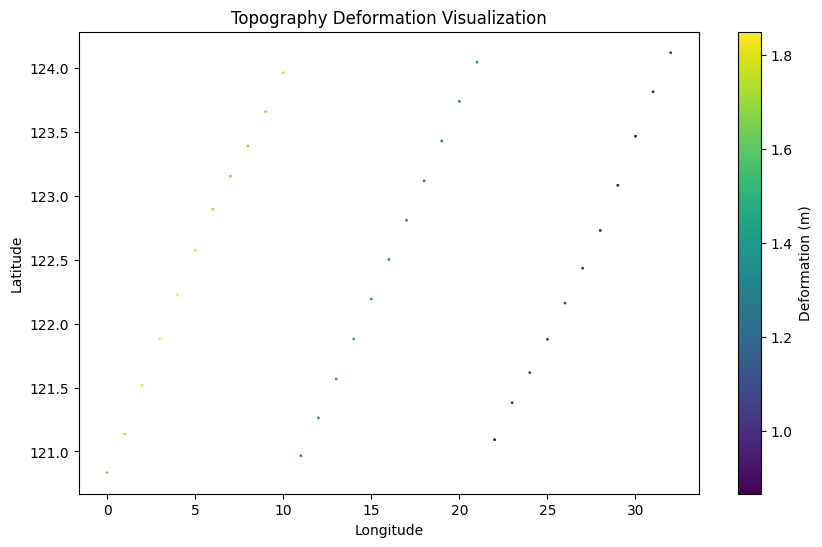

In [3]:
visualize_tt3('/Users/nephi/tsunamibayes/scenarios/north_sulawesi_forward/ruptfile.txt')

In [4]:
from clawpack.geoclaw import dtopotools

def generate_fault_from_dtopo(dtopo_path):
    """
    Generate a GeoClaw fault object from a .dtopo file.

    Parameters
    ----------
    dtopo_path : str
        Path to the .dtopo file.

    Returns
    -------
    fault : GeoClaw Fault object
        Fault object created from the .dtopo file.
    """
    # Read the dtopo file
    fault = dtopotools.read_dtopo(dtopo_path)
    
    # Visualize subfaults
    fault.plot_subfaults()
    
    return fault

In [5]:
# Example usage
dtopo_path = '/Users/nephi/tsunamibayes/scenarios/north_sulawesi_forward/ruptfile.txt'
fault = generate_fault_from_dtopo(dtopo_path)

AttributeError: module 'clawpack.geoclaw.dtopotools' has no attribute 'read_dtopo'

In [10]:
# Python
from clawpack.geoclaw import dtopotools

def generate_fault_from_dtopo(dtopo_path):
    """
    Generate a GeoClaw fault object from a .dtopo file.

    Parameters
    ----------
    dtopo_path : str
        Path to the .dtopo file.

    Returns
    -------
    fault : GeoClaw Fault object
        Fault object created from the .dtopo file.
    """
    # Load the dtopo file
    dtopo = dtopotools.DTopography()
    dtopo.read(dtopo_path, dtopo_type=3)  # Adjust `dtopo_type` based on your file format

    # Create a fault object manually if needed
    fault = dtopotools.Fault()
    fault.subfaults = dtopo.subfaults

    # Visualize subfaults
    fault.plot_subfaults()

    return fault

In [11]:

# Example usage
dtopo_path = '/Users/nephi/tsunamibayes/scenarios/north_sulawesi_forward/data/fq_files/sulawesi.rupt'
fault = generate_fault_from_dtopo(dtopo_path)

ValueError: cannot reshape array of size 14 into shape (1,0)

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_rupt(file_path):
    """
    Visualize rupture data from a .rupt file.

    Parameters
    ----------
    file_path : str
        Path to the .rupt file.

    Returns
    -------
    None
    """
    # Load the .rupt file
    data = np.loadtxt(file_path)

    # Extract columns (assuming lon, lat, slip, rupture time, risetime)
    lon = data[:, 0]
    lat = data[:, 1]
    slip = np.sqrt(data[:, 8]**2 + data[:, 9]**2)
    rupture_time = data[:, 3]
    risetime = data[:, 4]

    # Create a scatter plot for slip distribution
    plt.figure(figsize=(10, 6))
    plt.scatter(lon, lat, c=slip, cmap='Reds', s=10)
    plt.colorbar(label='Slip (m)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Slip Distribution Visualization')
    plt.show()

    # Create a scatter plot for rupture timing
    plt.figure(figsize=(10, 6))
    plt.scatter(lon, lat, c=rupture_time, cmap='Blues', s=10)
    plt.colorbar(label='Rupture Time (s)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Rupture Timing Visualization')
    plt.show()

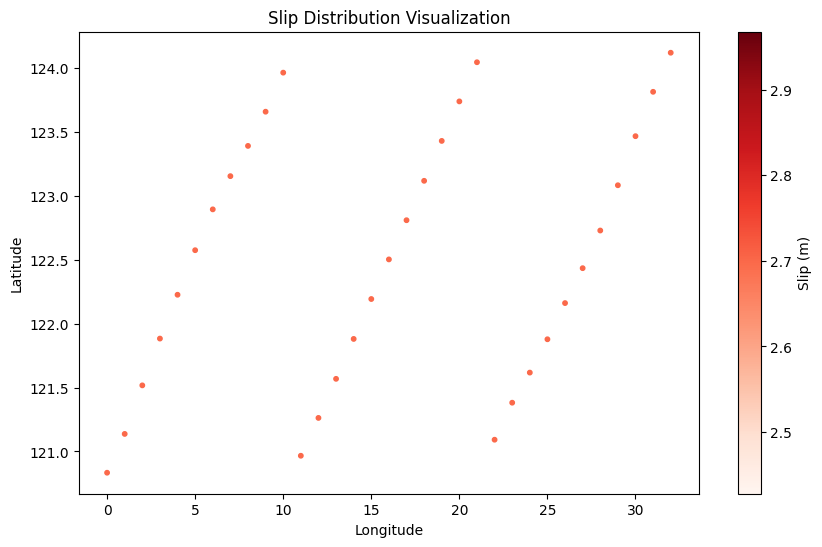

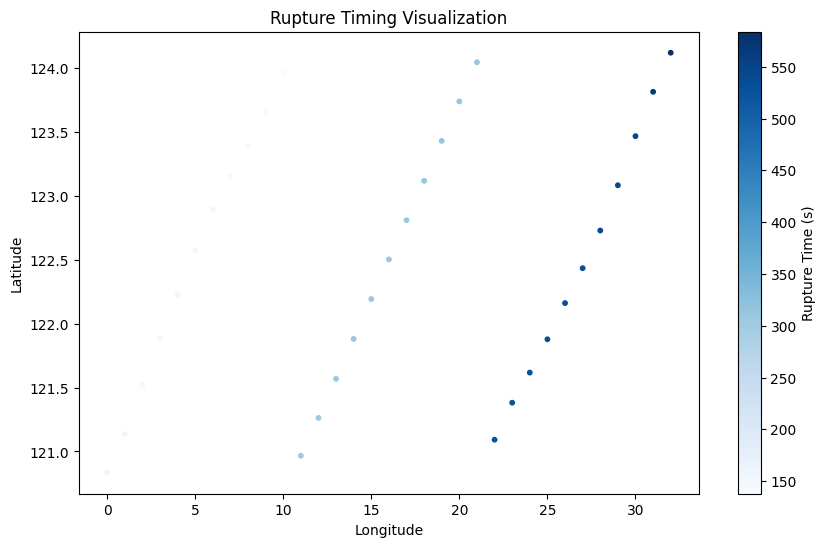

In [15]:
# Example usage
visualize_rupt('/Users/nephi/tsunamibayes/scenarios/north_sulawesi_forward/data/fq_files/sulawesi.rupt')

[<clawpack.geoclaw.dtopotools.SubFault object at 0x178208590>, <clawpack.geoclaw.dtopotools.SubFault object at 0x17841a650>, <clawpack.geoclaw.dtopotools.SubFault object at 0x178399810>, <clawpack.geoclaw.dtopotools.SubFault object at 0x1784389d0>, <clawpack.geoclaw.dtopotools.SubFault object at 0x1783f9f90>, <clawpack.geoclaw.dtopotools.SubFault object at 0x2970c11d0>, <clawpack.geoclaw.dtopotools.SubFault object at 0x1783a5e10>, <clawpack.geoclaw.dtopotools.SubFault object at 0x178375010>, <clawpack.geoclaw.dtopotools.SubFault object at 0x29e6ca250>, <clawpack.geoclaw.dtopotools.SubFault object at 0x29713e310>, <clawpack.geoclaw.dtopotools.SubFault object at 0x1781def90>, <clawpack.geoclaw.dtopotools.SubFault object at 0x1782bb990>, <clawpack.geoclaw.dtopotools.SubFault object at 0x1783dd350>, <clawpack.geoclaw.dtopotools.SubFault object at 0x1780cb950>, <clawpack.geoclaw.dtopotools.SubFault object at 0x1780ca110>, <clawpack.geoclaw.dtopotools.SubFault object at 0x17829e510>, <clawpa

/var/folders/j_/t2l5ty511_gcgj29jwr9n4sh0000gn/T/ipykernel_28151/3340803084.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  subs = pd.read_csv(ruptfile,header=None,delim_whitespace=True)


3..4..5..6..7..8..9..10..11..12..13..14..15..16..17..18..19..20..21..22..23..24..25..26..27..28..29..30..31..32..
Done
Making Okada dz for each of 33 subfaults
0..1..2..3..4..5..6..7..8..9..10..11..12..13..14..15..16..17..18..19..20..21..22..23..24..25..26..27..28..29..30..31..32..
Done


/var/folders/j_/t2l5ty511_gcgj29jwr9n4sh0000gn/T/ipykernel_28151/3340803084.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


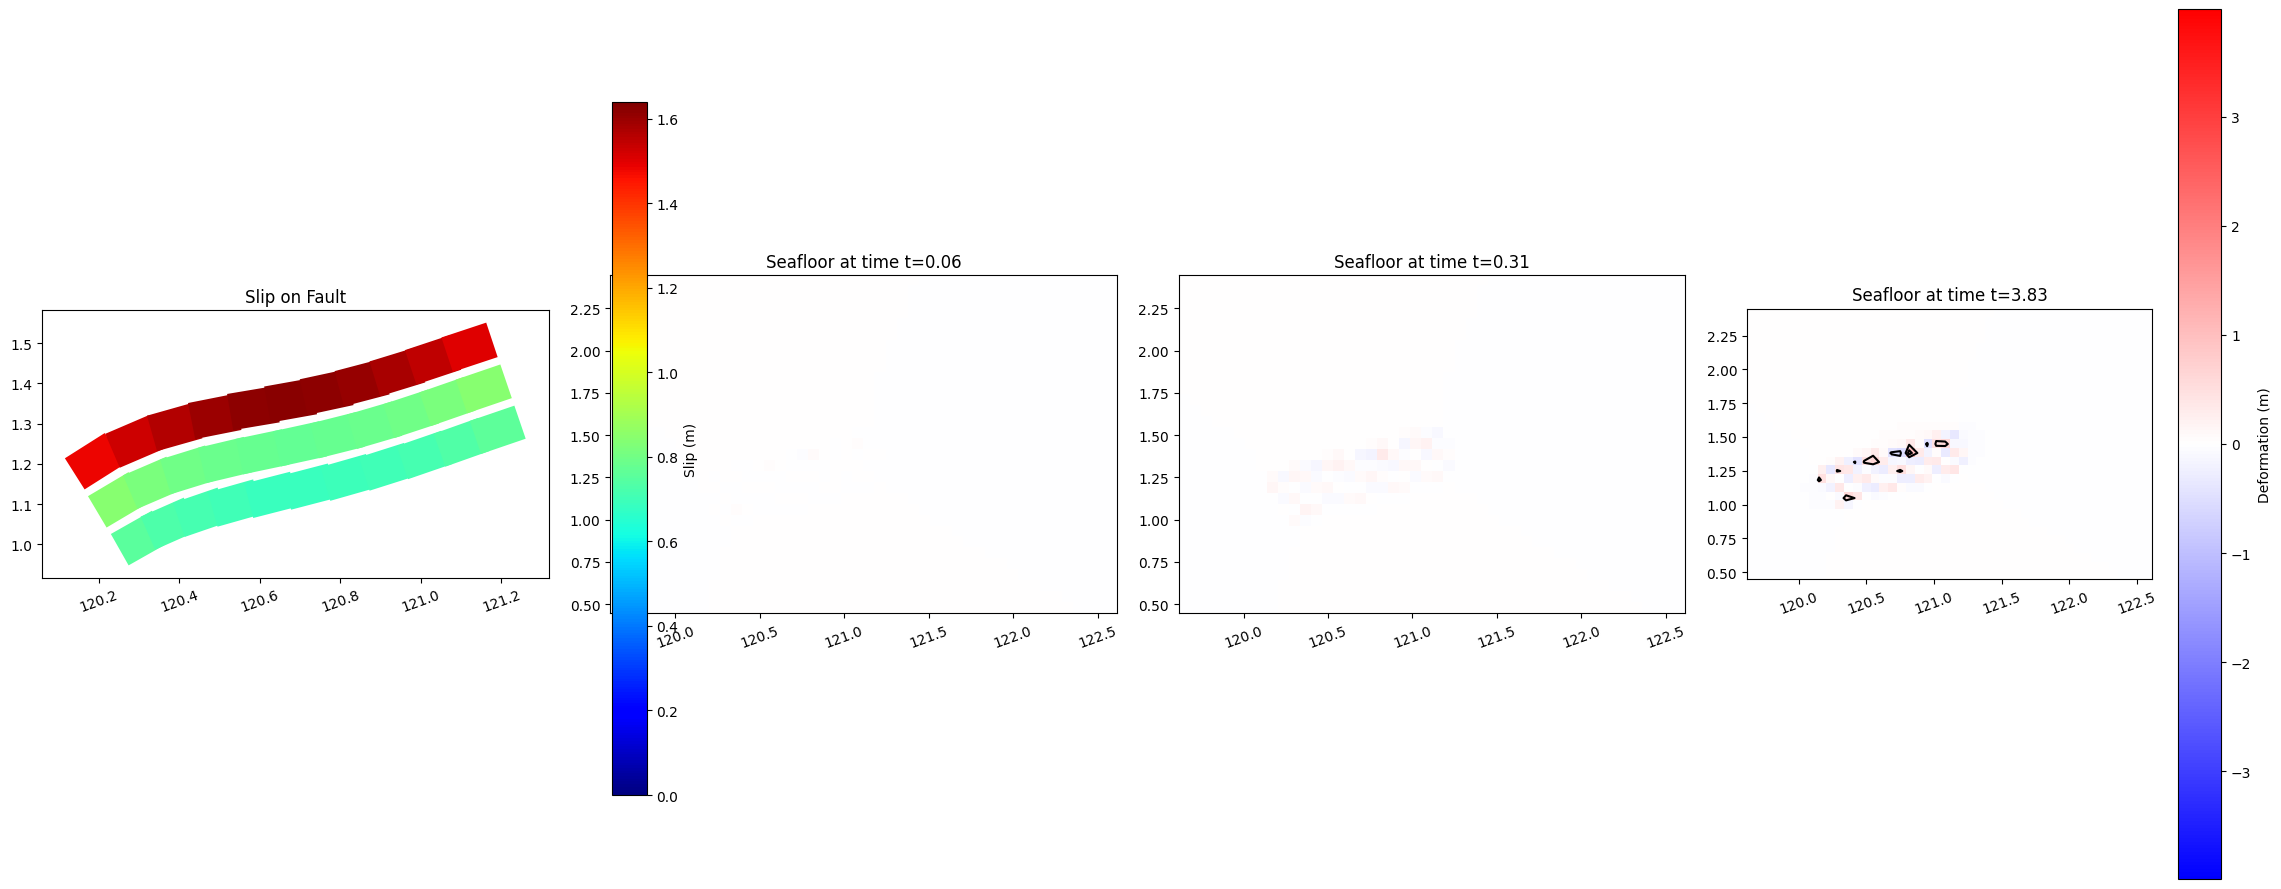

In [32]:
import matplotlib.pyplot as plt
from clawpack.geoclaw import dtopotools
from tsunamibayes import maketopo

# Define new rupture file and bounds
ruptfile = '/Users/nephi/tsunamibayes/scenarios/north_sulawesi_forward/data/fq_files/sulawesi.rupt'

subs = pd.read_csv(ruptfile,header=None,delim_whitespace=True)

columns = {0:'No',1: 'longitude', 2: 'latitude', 3: 'depth', 4: 'strike', 5: 'dip', 6: 'rise', 7: 'dura', 8: 'ss_slip', 9: 'ds_slip', 10: 'width', 11: 'length', 12: 'rupt_time'}
subs.rename(columns=columns, inplace=True)
subs['rake'] = 90

bounds = {'lon_min':-2, 'lon_max':10, 'lat_min':116, 'lat_max':129}  # Update with your region's bounds

# Generate fault deformation topology
b = maketopo.make_fault_dtopo(subs, bounds, ruptfile=ruptfile,verbose=True)


xb, yb = b.create_dtopo_xy(dx=4/60)  # Adjust resolution if needed
tfinalb = max([subfault.rupture_time + subfault.rise_time for subfault in b.subfaults])
dtopo0b = b.create_dtopography(xb, yb, verbose=True)

# Plot graphs
fig, (ax0, ax1, ax2, ax3) = plt.subplots(ncols=4, nrows=1, figsize=(23, 9))
b.plot_subfaults(axes=ax0, slip_color=True, plot_box=False)
ax0.set_title('Slip on Fault')

X = dtopo0b.X
Y = dtopo0b.Y
dZ_at_t = dtopo0b.dZ_at_t
dz_max = dtopo0b.dZ.max()

# Plot seafloor deformation at different times
for i, t0 in enumerate([0.01 * tfinalb, 0.05 * tfinalb, 0.6 * tfinalb]):
    ax = [ax1, ax2, ax3][i]
    dtopotools.plot_dZ_colors(X, Y, dZ_at_t(t0), axes=ax, cmax_dZ=dz_max * 4, add_colorbar=(i == 2))
    ax.set_title(f'Seafloor at time t={str(t0)[:4]}')

plt.tight_layout()
plt.show()